# 社区食堂对周边商业生态的影响：空间 DID 实证分析

## 报告摘要

本研究以社区食堂第一次出现在年度商户数据中的年份作为冲击时点，比较同一家社区食堂周围**近距离处理圈**与**稍远对照圈**在冲击前后的相对变化，并使用双重差分（DID）识别社区食堂出现对周边商业生态的影响。

本次分析得到的核心结果为：

- 共识别 **382 家**社区食堂设施，构造 2012-2022 年完整空间面板，共 **33,616 行**。
- 比较 4 种空间口径和 2 种事件窗口后，最优规格为 **R500 + n=3**：0-500 m 为处理圈，500-1000 m 为对照圈，观察冲击前后各 3 年。
- 6 个核心指标中，**5/6 通过 pooled Event Study 的政策前联合检验**。
- 主 DID 中，评论数量约增加 **10.24%**，单店平均评论约增加 **8.41%**，两项均在 1% 水平附近显著且通过平行趋势复检。
- 活跃商户总量、餐饮商户数量、同质化快餐数量和存活率未发现统计显著变化。
- 平均价格虽然估计为正，但其 pooled 平行趋势未通过，因此只作描述性解释。
- 异质性分析中，中高价餐饮活跃商户数量约增加 **20.79%**，并通过该分组自己的平行趋势复检。

> **识别原则：** 平行趋势检验的含义是“没有发现显著的政策前差异趋势”，而不是数学意义上证明处理组与对照组必然平行。

---

## 研究流程

**原始商户年度数据**  
→ **清洗并识别社区食堂**  
→ **第一次出现年份定义为冲击点**  
→ **构造 4 套近圈/远圈空间方案**  
→ **形成设施-环带-年份平衡面板**  
→ **逐设施平行趋势筛选**  
→ **pooled Event Study 复检**  
→ **选择最优空间与时间规格**  
→ **正式 DID**  
→ **异质性分组重新检验平行趋势并估计 DID**


# 1. 原始数据接入

本节只负责把两份大型年度商户数据稳定接入分析环境，不在这一阶段筛选 DID 样本。

处理步骤：

1. 检查 `stateRes_dzdp1.rar` 与 `tourist_dzdp2.rar` 是否已经解压；若已有 CSV，则不重复解压。
2. 自动寻找 7-Zip 或 WinRAR。
3. 使用 DuckDB 流式注册两份 CSV，并统一形成 `raw_all` 视图。
4. 原始字段先按字符串读入，后续再显式转换数值类型，以降低大型 CSV 因类型推断不一致导致的读取失败风险。
5. 在 Windows 环境中注册中文字体，保证后续图表导出 PDF 时中文正常显示。

这一阶段的核心结果是：**原始数据已经进入 DuckDB，但尚未进行空间处理或 DID 建模。**


In [1]:
from pathlib import Path
import os
import shutil
import subprocess
import warnings

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import BallTree
import statsmodels.api as sm
from scipy.stats import chi2
from linearmodels.iv import AbsorbingLS

warnings.filterwarnings("ignore")


# PDF/报告模式：保留计算，关闭过程性日志输出
REPORT_MODE = True

def vprint(*args, **kwargs):
    if not REPORT_MODE:
        print(*args, **kwargs)


# ============================================================
# 路径
# ============================================================

ROOT = Path(r"C:\Users\Administrator\Desktop\fly")

RAR_STATE = ROOT / "stateRes_dzdp1.rar"
RAR_TOURIST = ROOT / "tourist_dzdp2.rar"

DIR_STATE = ROOT / "stateRes_dzdp1"
DIR_TOURIST = ROOT / "tourist_dzdp2"

OUT_DIR = ROOT / "processed"
OUT_DIR.mkdir(parents=True, exist_ok=True)

DB_PATH = ROOT / "dzdp_did.duckdb"

DUCKDB_TMP = ROOT / "duckdb_tmp"
DUCKDB_TMP.mkdir(parents=True, exist_ok=True)

# ============================================================
# Matplotlib 全局中文字体
# ============================================================

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager
from pathlib import Path


def setup_chinese_font():

    # 优先使用 Windows 常见中文字体
    font_files = [
        r"C:\Windows\Fonts\msyh.ttc",      # 微软雅黑
        r"C:\Windows\Fonts\msyhbd.ttc",    # 微软雅黑 Bold
        r"C:\Windows\Fonts\simhei.ttf",    # 黑体
        r"C:\Windows\Fonts\simsun.ttc",    # 宋体
    ]

    selected_font = None

    for font_path in font_files:

        if Path(font_path).exists():

            try:
                font_manager.fontManager.addfont(
                    font_path
                )

                selected_font = (
                    font_manager.FontProperties(
                        fname=font_path
                    ).get_name()
                )

                break

            except Exception:
                pass

    # 如果上面的路径没找到，再从 Matplotlib 字体库找
    if selected_font is None:

        available_fonts = {
            f.name
            for f in font_manager.fontManager.ttflist
        }

        candidates = [
            "Microsoft YaHei",
            "SimHei",
            "SimSun",
            "Noto Sans CJK SC",
            "Source Han Sans CN",
        ]

        for name in candidates:

            if name in available_fonts:
                selected_font = name
                break

    if selected_font is None:

        vprint("⚠️ 没找到可用中文字体")

    else:

        mpl.rcParams["font.family"] = "sans-serif"

        mpl.rcParams["font.sans-serif"] = [
            selected_font,
            "DejaVu Sans",
        ]

        # 防止负号显示成方块
        mpl.rcParams["axes.unicode_minus"] = False

        vprint(
            "Matplotlib 中文字体:",
            selected_font
        )


setup_chinese_font()

# ============================================================
# 找解压程序
# ============================================================

def find_extractor():

    candidates = [
        shutil.which("7z"),
        shutil.which("7z.exe"),
        shutil.which("WinRAR"),
        shutil.which("WinRAR.exe"),

        r"C:\Program Files\7-Zip\7z.exe",
        r"C:\Program Files (x86)\7-Zip\7z.exe",

        r"C:\Program Files\WinRAR\WinRAR.exe",
        r"C:\Program Files (x86)\WinRAR\WinRAR.exe",
    ]

    for p in candidates:

        if p and Path(p).exists():
            return Path(p)

    return None


def extract_rar(rar_path, out_dir):

    out_dir.mkdir(parents=True, exist_ok=True)

    # 已经有 csv 就不重复解压
    existing = list(out_dir.rglob("*.csv"))

    if existing:
        vprint(f"[SKIP] 已解压: {rar_path.name}")
        return

    extractor = find_extractor()

    if extractor is None:
        raise RuntimeError(
            "没有找到 7-Zip 或 WinRAR。"
        )

    vprint(f"[EXTRACT] {rar_path}")

    exe_name = extractor.name.lower()

    if "7z" in exe_name:

        cmd = [
            str(extractor),
            "x",
            str(rar_path),
            f"-o{out_dir}",
            "-y",
        ]

    else:

        cmd = [
            str(extractor),
            "x",
            "-o+",
            str(rar_path),
            str(out_dir) + "\\",
        ]

    subprocess.run(
        cmd,
        check=True
    )


extract_rar(
    RAR_STATE,
    DIR_STATE
)

extract_rar(
    RAR_TOURIST,
    DIR_TOURIST
)


# ============================================================
# 找 CSV
# ============================================================

state_csvs = sorted(
    DIR_STATE.rglob("*.csv")
)

tourist_csvs = sorted(
    DIR_TOURIST.rglob("*.csv")
)

vprint("\nstate csv:")
for p in state_csvs:
    vprint(" ", p)

vprint("\ntourist csv:")
for p in tourist_csvs:
    vprint(" ", p)

if not state_csvs:
    raise RuntimeError("stateRes_dzdp1 没找到 CSV")

if not tourist_csvs:
    raise RuntimeError("tourist_dzdp2 没找到 CSV")


# ============================================================
# DuckDB
# ============================================================

con = duckdb.connect(
    str(DB_PATH)
)

con.execute("PRAGMA threads=8")
con.execute("PRAGMA memory_limit='8GB'")

con.execute(
    f"SET temp_directory='{DUCKDB_TMP.as_posix()}'"
)


def duckdb_file_list(paths):

    return "[" + ",".join(
        "'" + p.as_posix().replace("'", "''") + "'"
        for p in paths
    ) + "]"


state_list = duckdb_file_list(
    state_csvs
)

tourist_list = duckdb_file_list(
    tourist_csvs
)


# ============================================================
# 注册原始 VIEW
# ============================================================

con.execute(f"""
CREATE OR REPLACE VIEW raw_state AS
SELECT *
FROM read_csv_auto(
    {state_list},
    all_varchar=true,
    union_by_name=true,
    filename=true,
    ignore_errors=true
)
""")


con.execute(f"""
CREATE OR REPLACE VIEW raw_tourist AS
SELECT *
FROM read_csv_auto(
    {tourist_list},
    all_varchar=true,
    union_by_name=true,
    filename=true,
    ignore_errors=true
)
""")


con.execute("""
CREATE OR REPLACE VIEW raw_all AS

SELECT * FROM raw_state

UNION ALL BY NAME

SELECT * FROM raw_tourist
""")


vprint("\n注册完成:")

vprint(
    con.execute(
        "SHOW TABLES"
    ).df()
)


# 2. 商户清洗、社区食堂识别与空间面板构造

## 2.1 基础清洗

依据研究说明，对原始商户年度记录进行以下处理：

- 只保留 2012-2022 年；
- `shop_id` 统一为字符串；
- 经纬度使用 WGS 坐标，并限制在合理中国范围；
- 人均价格小于 0 或大于 5000 时设为缺失；
- 评论数量统一定义为：

$$
comments_{it}=\max(all\_remarks_{it},\ review\_count_{it})
$$

- 同一个 `year + shop_id` 在两份数据中重复出现时只保留一条；
- 识别社区食堂、餐饮商户和同质化快餐小吃商户。

## 2.2 冲击年份

对每一家被识别为社区食堂的设施，将其第一次在年度数据中出现的年份定义为：

$$
opening\_year_i=\min(year_i)
$$

并定义事件时间：

$$
rel\_year_{it}=year_t-opening\_year_i
$$

其中 `rel_year = 0` 为冲击年份，`-1` 表示冲击前一年，`+1` 表示冲击后一年。

## 2.3 空间处理组与对照组

使用 BallTree 与 Haversine 距离，在每一年为每一家社区食堂寻找 1 km 内周边商户，并构造四套空间口径：

| 规格 | 处理组 | 对照组 |
|---|---|---|
| R100 | 0-100 m | 100-500 m |
| R200 | 0-200 m | 200-600 m |
| R300 | 0-300 m | 300-700 m |
| R500 | 0-500 m | 500-1000 m |

社区食堂自身不计入周边商户。如果某个对照组商户同时落入另一家社区食堂的处理圈，则从该对照组剔除，以降低“对照组也受到处理”的污染。

## 2.4 设施-环带-年份面板

匹配结果按以下层级聚合：

$$
facility \times scheme \times ring \times year
$$

结果变量包括活跃商户数、餐饮商户数、同质化快餐商户数、非餐饮商户数、闭店数、评论数量、单店平均评论、平均价格和平均星级。

随后构造完整平衡面板。计数变量缺失补 0；连续变量沿同一设施-环带时间序列插值，再使用同年中位数和总体中位数补足。

## 2.5 DID 与存活率变量

定义：

$$
post_{it}=\mathbf{1}(rel\_year_{it}\ge 0)
$$

$$
did_{irt}=treat\_ring_r\times post_{it}
$$

存活率指数采用当年活跃商户数相对于政策前平均活跃商户数的比例：

$$
Survival_{irt}=\frac{Active_{irt}}{\overline{Active}_{ir,pre}}
$$

商户数量和评论类变量使用 $\ln(1+x)$ 变换。

### 本次数据质量检查

- 社区食堂设施数：**382**
- 年份：**2012-2022，共 11 年**
- 4 套空间口径 × 2 个环带
- 完整面板行数：

$$
382\times4\times2\times11=33,616
$$

实际面板行数与理论值完全一致，说明平衡面板结构完整。

R500 下，0-500 m 处理圈的活跃商户均值约为 **613.08**，500-1000 m 对照圈均值约为 **1025.24**。两组水平不同本身不是问题，因为 DID 要求的是**冲击前变化趋势可比，而不是水平相等**。


In [2]:
# ============================================================
# 配置
# ============================================================

SHOPS_PATH = OUT_DIR / "shops_clean.parquet"
FACILITY_PATH = OUT_DIR / "facilities_clean.parquet"
PANEL_PATH = OUT_DIR / "spatial_panel_v2.parquet"

EARTH_RADIUS_KM = 6371.0088


SCHEMES = {
    "R100": {
        "treat_max": 0.1,
        "control_max": 0.5,
        "label": "0-100m vs 100-500m",
    },

    "R200": {
        "treat_max": 0.2,
        "control_max": 0.6,
        "label": "0-200m vs 200-600m",
    },

    "R300": {
        "treat_max": 0.3,
        "control_max": 0.7,
        "label": "0-300m vs 300-700m",
    },

    "R500": {
        "treat_max": 0.5,
        "control_max": 1.0,
        "label": "0-500m vs 500-1000m",
    },
}


# ============================================================
# 1. 商户清洗
#
# 保留当前识别和去重逻辑，不做修改
# ============================================================

clean_sql = r"""
WITH typed AS (

    SELECT

        TRY_CAST(year AS INTEGER) AS year,

        NULLIF(
            TRIM(
                CAST(shop_id AS VARCHAR)
            ),
            ''
        ) AS shop_id,

        NULLIF(TRIM(name), '') AS name,
        NULLIF(TRIM(alias), '') AS alias,

        TRY_CAST(
            lon_wgs AS DOUBLE
        ) AS lon_wgs,

        TRY_CAST(
            lat_wgs AS DOUBLE
        ) AS lat_wgs,

        NULLIF(TRIM(PAC), '') AS PAC,

        NULLIF(
            TRIM(province19),
            ''
        ) AS province19,

        NULLIF(
            TRIM(city19),
            ''
        ) AS city19,

        NULLIF(
            TRIM(county19),
            ''
        ) AS county19,

        NULLIF(
            TRIM(big_cate),
            ''
        ) AS big_cate,

        NULLIF(
            TRIM(small_cate),
            ''
        ) AS small_cate,

        NULLIF(
            TRIM(address),
            ''
        ) AS address,


        CASE
            WHEN TRY_CAST(
                avg_price AS DOUBLE
            ) BETWEEN 0 AND 5000

            THEN TRY_CAST(
                avg_price AS DOUBLE
            )

            ELSE NULL
        END AS avg_price,


        CASE
            WHEN TRY_CAST(
                stars AS DOUBLE
            ) BETWEEN 0 AND 5

            THEN TRY_CAST(
                stars AS DOUBLE
            )

            ELSE NULL
        END AS stars,


        CASE
            WHEN TRY_CAST(
                all_remarks AS DOUBLE
            ) >= 0

            THEN TRY_CAST(
                all_remarks AS DOUBLE
            )

            ELSE NULL
        END AS all_remarks,


        CASE
            WHEN TRY_CAST(
                review_count AS DOUBLE
            ) >= 0

            THEN TRY_CAST(
                review_count AS DOUBLE
            )

            ELSE NULL
        END AS review_count,


        CASE

            WHEN LOWER(
                TRIM(is_closed)
            ) IN (
                'yes','true','1'
            )
            THEN 1

            WHEN LOWER(
                TRIM(is_closed)
            ) IN (
                'no','false','0'
            )
            THEN 0

            ELSE NULL

        END AS is_closed,


        CONCAT_WS(
            ' ',
            COALESCE(name, ''),
            COALESCE(alias, '')
        ) AS identity_text,


        CONCAT_WS(
            ' ',
            COALESCE(tag, ''),
            COALESCE(tag2, ''),
            COALESCE(tags, '')
        ) AS tag_text,


        CONCAT_WS(
            ' ',
            COALESCE(navigation, ''),
            COALESCE(description, '')
        ) AS context_text,


        CONCAT_WS(
            ' ',
            COALESCE(name, ''),
            COALESCE(big_cate, ''),
            COALESCE(small_cate, ''),
            COALESCE(tag, ''),
            COALESCE(tag2, ''),
            COALESCE(tags, '')
        ) AS food_text,

        filename AS source_file

    FROM raw_all
),

valid AS (

    SELECT
        *,

        CASE

            WHEN all_remarks IS NULL
             AND review_count IS NULL

            THEN NULL

            ELSE GREATEST(
                COALESCE(
                    all_remarks,
                    0
                ),
                COALESCE(
                    review_count,
                    0
                )
            )

        END AS comments

    FROM typed

    WHERE year BETWEEN 2012 AND 2022

      AND shop_id IS NOT NULL

      AND lon_wgs BETWEEN 73 AND 136
      AND lat_wgs BETWEEN 3 AND 54
),

classified AS (

    SELECT
        *,

        CASE

            WHEN REGEXP_MATCHES(
                identity_text,

                '社区食堂|社区餐厅|社区助餐|助餐中心|助餐点|助餐站|助餐服务|长者食堂|老人食堂|老年食堂|养老食堂|幸福食堂|爱心食堂|惠民食堂'
            )
            THEN 3

            WHEN REGEXP_MATCHES(
                tag_text,

                '社区食堂|社区助餐|助餐中心|长者食堂|老年食堂|幸福食堂|爱心食堂'
            )
            THEN 2

            WHEN REGEXP_MATCHES(
                context_text,

                '社区食堂|社区助餐|助餐中心|助餐点|长者食堂|老年食堂|幸福食堂|爱心食堂'
            )
            THEN 1

            ELSE 0

        END AS facility_confidence,


        CASE

            WHEN REGEXP_MATCHES(
                CONCAT_WS(
                    ' ',
                    identity_text,
                    tag_text
                ),

                '员工食堂|学校食堂|医院食堂|公司食堂|工厂食堂|单位食堂|机关食堂|食堂承包|自助餐厅'
            )

            THEN 1

            ELSE 0

        END AS facility_excluded,


        CASE

            WHEN big_cate = '美食'

              OR REGEXP_MATCHES(
                  food_text,

                  '餐厅|餐饮|小吃|快餐|火锅|烧烤|饮品|面包|甜点'
              )

            THEN 1

            ELSE 0

        END AS is_food

    FROM valid
),

classified2 AS (

    SELECT
        *,

        CASE
            WHEN facility_confidence >= 2
             AND facility_excluded = 0
            THEN 1
            ELSE 0
        END AS is_community_canteen,


        CASE

            WHEN is_food = 1

             AND (

                 REGEXP_MATCHES(
                     food_text,

                     '小吃|快餐|简餐|面食|粉面|米线|馄饨|饺子|便当|盖浇饭'
                 )

                 OR avg_price <= 30

             )

            THEN 1

            ELSE 0

        END AS is_homogeneous_fastfood

    FROM classified
),

scored AS (

    SELECT
        *,

        facility_confidence * 100

        + CAST(
            name IS NOT NULL
            AS INTEGER
        )

        + CAST(
            city19 IS NOT NULL
            AS INTEGER
        )

        + CAST(
            county19 IS NOT NULL
            AS INTEGER
        )

        + CAST(
            avg_price IS NOT NULL
            AS INTEGER
        )

        + CAST(
            stars IS NOT NULL
            AS INTEGER
        )

        + CAST(
            comments IS NOT NULL
            AS INTEGER
        )

        AS quality_score

    FROM classified2
),

dedup AS (

    SELECT *

    FROM scored

    QUALIFY ROW_NUMBER() OVER (

        PARTITION BY
            year,
            shop_id

        ORDER BY
            quality_score DESC,
            source_file

    ) = 1
)

SELECT

    year,
    shop_id,
    name,

    lon_wgs,
    lat_wgs,

    PAC,
    province19,
    city19,
    county19,

    address,

    big_cate,
    small_cate,

    avg_price,

    stars,

    CASE
        WHEN stars > 0
        THEN stars
        ELSE NULL
    END AS valid_stars,

    all_remarks,
    review_count,
    comments,

    is_closed,

    facility_confidence,
    facility_excluded,

    is_community_canteen,

    is_food,
    is_homogeneous_fastfood,

    source_file

FROM dedup
"""


vprint("1/5 清洗商户数据...")

con.execute(f"""
COPY (
    {clean_sql}
)
TO '{SHOPS_PATH.as_posix()}'
(
    FORMAT PARQUET,
    COMPRESSION ZSTD,
    ROW_GROUP_SIZE 250000
)
""")


con.execute(f"""
CREATE OR REPLACE VIEW shops_clean AS
SELECT *
FROM read_parquet(
    '{SHOPS_PATH.as_posix()}'
)
""")


# ============================================================
# 2. 社区食堂设施
#
# opening_year =
# 第一次作为社区食堂出现的年份
#
# 坐标使用多年 median
# ============================================================

vprint("2/5 生成社区食堂设施...")

con.execute(f"""
COPY (

    SELECT

        shop_id AS facility_id,

        MIN(year)
            AS opening_year,

        MAX(year)
            AS last_seen_year,

        COUNT(
            DISTINCT year
        ) AS observed_years,

        ANY_VALUE(name)
            AS name,

        MEDIAN(lon_wgs)
            AS lon_wgs,

        MEDIAN(lat_wgs)
            AS lat_wgs,

        ANY_VALUE(PAC)
            AS PAC,

        ANY_VALUE(province19)
            AS province19,

        ANY_VALUE(city19)
            AS city19,

        ANY_VALUE(county19)
            AS county19,

        MAX(
            facility_confidence
        ) AS facility_confidence

    FROM shops_clean

    WHERE is_community_canteen = 1

    GROUP BY shop_id

)
TO '{FACILITY_PATH.as_posix()}'
(
    FORMAT PARQUET,
    COMPRESSION ZSTD
)
""")


con.execute(f"""
CREATE OR REPLACE VIEW facilities_clean AS
SELECT *
FROM read_parquet(
    '{FACILITY_PATH.as_posix()}'
)
""")


fac = con.execute("""
SELECT *
FROM facilities_clean
ORDER BY facility_id
""").df()

fac["facility_id"] = (
    fac["facility_id"]
    .astype(str)
)


vprint(
    "facilities:",
    len(fac)
)


# ============================================================
# 3. BallTree 空间匹配
#
# 这里不保存几千万 pair
# 每一年匹配后直接聚合
#
# 逻辑和文档一致：
#
# R100  0-100 / 100-500
# R200  0-200 / 200-600
# R300  0-300 / 300-700
# R500  0-500 / 500-1000
#
# control 如果落入任意其他食堂 treatment
# 就从 control 删除
# ============================================================

vprint("3/5 空间匹配并聚合...")

fac_rad = np.radians(
    fac[
        [
            "lat_wgs",
            "lon_wgs"
        ]
    ].to_numpy()
)


annual_agg = []


for year in range(
    2012,
    2023
):

    vprint(
        f"  spatial year {year}"
    )

    shops = con.execute(f"""
        SELECT

            shop_id,
            lon_wgs,
            lat_wgs,

            is_food,
            is_homogeneous_fastfood,
            is_closed,

            avg_price,
            valid_stars,
            comments

        FROM shops_clean

        WHERE year = {year}
    """).df()

    if shops.empty:
        continue

    shops["shop_id"] = (
        shops["shop_id"]
        .astype(str)
    )

    coords = np.radians(
        shops[
            [
                "lat_wgs",
                "lon_wgs"
            ]
        ].to_numpy()
    )

    tree = BallTree(
        coords,
        metric="haversine"
    )

    indexes, distances = (
        tree.query_radius(
            fac_rad,

            r=(
                1.0
                / EARTH_RADIUS_KM
            ),

            return_distance=True,

            sort_results=True
        )
    )


    pair_blocks = []


    for i, (
        idx,
        dist
    ) in enumerate(
        zip(
            indexes,
            distances
        )
    ):

        if len(idx) == 0:
            continue

        x = shops.iloc[
            idx
        ].copy()

        x["facility_id"] = (
            fac.iloc[i][
                "facility_id"
            ]
        )

        x["opening_year"] = (
            fac.iloc[i][
                "opening_year"
            ]
        )

        x["distance_km"] = (
            dist
            * EARTH_RADIUS_KM
        )

        # 食堂自身排除
        x = x[
            x["shop_id"]
            != x["facility_id"]
        ]

        pair_blocks.append(x)


    if not pair_blocks:
        continue


    pairs = pd.concat(
        pair_blocks,
        ignore_index=True
    )


    # ========================================================
    # 每个 scheme 分别处理
    # ========================================================

    for scheme, cfg in SCHEMES.items():

        treat_max = (
            cfg["treat_max"]
        )

        control_max = (
            cfg["control_max"]
        )


        x = pairs[
            pairs["distance_km"]
            <= control_max
        ].copy()


        x["scheme"] = scheme


        # ----------------------------------------------------
        # 环带
        #
        # <= treat_max        Treatment
        # > treat_max         Control
        # <= control_max
        # ----------------------------------------------------

        x["treat_ring"] = (
            x["distance_km"]
            <= treat_max
        ).astype("int8")


        # ----------------------------------------------------
        # control contamination
        #
        # 一个 shop 只要处于任何设施 treatment ring
        # 就不能成为其他设施 control
        # ----------------------------------------------------

        treated_shop_ids = set(
            x.loc[
                x["treat_ring"] == 1,
                "shop_id"
            ]
        )


        x = x[
            ~(
                (x["treat_ring"] == 0)
                &
                (
                    x["shop_id"]
                    .isin(
                        treated_shop_ids
                    )
                )
            )
        ].copy()


        # ----------------------------------------------------
        # active / category indicator
        #
        # DuckDB -> pandas 后整数列可能是 nullable Int64，
        # 内部可能包含 pd.NA。
        # 在生成 0/1 指标之前统一处理掉 NA。
        #
        # 规则：
        # is_closed 缺失 -> 暂按未闭店处理
        # is_food 缺失 -> 非餐饮
        # is_homogeneous_fastfood 缺失 -> 非快餐小吃
        # ----------------------------------------------------

        x["is_closed_num"] = (
            pd.to_numeric(
                x["is_closed"],
                errors="coerce"
            )
            .fillna(0)
            .astype("int8")
        )

        x["is_food_num"] = (
            pd.to_numeric(
                x["is_food"],
                errors="coerce"
            )
            .fillna(0)
            .astype("int8")
        )

        x["is_fastfood_num"] = (
            pd.to_numeric(
                x["is_homogeneous_fastfood"],
                errors="coerce"
            )
            .fillna(0)
            .astype("int8")
        )


        # 活跃商户
        x["active"] = np.where(
            x["is_closed_num"] == 1,
            0,
            1
        ).astype("int8")


        # 活跃餐饮商户
        x["food_active"] = np.where(
            (x["active"] == 1)
            &
            (x["is_food_num"] == 1),
            1,
            0
        ).astype("int8")


        # 活跃同质化快餐小吃
        x["fastfood_active"] = np.where(
            (x["active"] == 1)
            &
            (x["is_fastfood_num"] == 1),
            1,
            0
        ).astype("int8")


        # 活跃非餐饮
        x["nonfood_active"] = np.where(
            (x["active"] == 1)
            &
            (x["is_food_num"] == 0),
            1,
            0
        ).astype("int8")


        # 闭店商户
        x["closed"] = np.where(
            x["is_closed_num"] == 1,
            1,
            0
        ).astype("int8")


        # ----------------------------------------------------
        # 聚合 facility × ring × year
        # ----------------------------------------------------

        g = (
            x.groupby(
                [
                    "facility_id",
                    "opening_year",
                    "scheme",
                    "treat_ring"
                ],
                as_index=False
            )
            .agg(

                active_count=(
                    "active",
                    "sum"
                ),

                food_count=(
                    "food_active",
                    "sum"
                ),

                fastfood_count=(
                    "fastfood_active",
                    "sum"
                ),

                nonfood_count=(
                    "nonfood_active",
                    "sum"
                ),

                closed_count=(
                    "closed",
                    "sum"
                ),

                comments=(
                    "comments",
                    "sum"
                ),

                avg_comments_per_shop=(
                    "comments",
                    "mean"
                ),

                avg_price=(
                    "avg_price",
                    "mean"
                ),

                avg_stars=(
                    "valid_stars",
                    "mean"
                ),
            )
        )


        g["year"] = year

        annual_agg.append(g)


ring_year = pd.concat(
    annual_agg,
    ignore_index=True
)


# ============================================================
# 4. 完整平衡面板
# ============================================================

vprint("4/5 构造完整平衡面板...")


grid = pd.MultiIndex.from_product(
    [
        fac["facility_id"],
        list(SCHEMES.keys()),
        [0, 1],
        range(2012, 2023),
    ],

    names=[
        "facility_id",
        "scheme",
        "treat_ring",
        "year",
    ]
).to_frame(
    index=False
)


meta_cols = [
    "facility_id",
    "opening_year",
    "name",
    "lon_wgs",
    "lat_wgs",
    "PAC",
    "province19",
    "city19",
    "county19",
]


panel = grid.merge(
    fac[meta_cols],
    on="facility_id",
    how="left"
)


ring_year["facility_id"] = (
    ring_year["facility_id"]
    .astype(str)
)


panel = panel.merge(
    ring_year.drop(
        columns=[
            "opening_year"
        ]
    ),

    on=[
        "facility_id",
        "scheme",
        "treat_ring",
        "year"
    ],

    how="left"
)


# ============================================================
# 计数变量补0
# ============================================================

count_cols = [
    "active_count",
    "food_count",
    "fastfood_count",
    "nonfood_count",
    "closed_count",
    "comments",
]


panel[count_cols] = (
    panel[count_cols]
    .fillna(0)
)


# ============================================================
# 连续变量沿用之前插值方法
# ============================================================

continuous_cols = [
    "avg_comments_per_shop",
    "avg_price",
    "avg_stars",
]


panel = panel.sort_values(
    [
        "facility_id",
        "scheme",
        "treat_ring",
        "year",
    ]
)


for col in continuous_cols:

    panel[col] = (
        panel.groupby(
            [
                "facility_id",
                "scheme",
                "treat_ring",
            ]
        )[col]
        .transform(
            lambda s:
            s.interpolate(
                limit_direction="both"
            )
        )
    )


    year_med = (
        panel.groupby(
            "year"
        )[col]
        .transform(
            "median"
        )
    )


    panel[col] = (
        panel[col]
        .fillna(
            year_med
        )
        .fillna(
            panel[col].median()
        )
    )


# ============================================================
# DID / event time
# ============================================================

panel["rel_year"] = (
    panel["year"]
    - panel["opening_year"]
)


panel["post"] = (
    panel["rel_year"] >= 0
).astype("int8")


panel["did"] = (
    panel["treat_ring"]
    * panel["post"]
)


# ============================================================
# 5. survival index
#
# 基准：
# 同一 facility + scheme + ring
# 所有政策前年份 active_count 的平均值
# ============================================================

vprint("5/5 生成 survival_index...")


baseline = (
    panel[
        panel["rel_year"] < 0
    ]
    .groupby(
        [
            "facility_id",
            "scheme",
            "treat_ring"
        ],
        as_index=False
    )["active_count"]
    .mean()
    .rename(
        columns={
            "active_count":
            "pre_active_baseline"
        }
    )
)


panel = panel.merge(
    baseline,

    on=[
        "facility_id",
        "scheme",
        "treat_ring"
    ],

    how="left"
)


panel["survival_index"] = np.where(

    panel[
        "pre_active_baseline"
    ] > 0,

    panel["active_count"]
    /
    panel[
        "pre_active_baseline"
    ],

    np.nan
)


# survival 属连续变量
# 按文档思路继续补值

panel = panel.sort_values(
    [
        "facility_id",
        "scheme",
        "treat_ring",
        "year"
    ]
)


panel["survival_index"] = (
    panel.groupby(
        [
            "facility_id",
            "scheme",
            "treat_ring"
        ]
    )["survival_index"]
    .transform(
        lambda s:
        s.interpolate(
            limit_direction="both"
        )
    )
)


year_med = (
    panel.groupby(
        "year"
    )["survival_index"]
    .transform(
        "median"
    )
)


panel["survival_index"] = (
    panel[
        "survival_index"
    ]
    .fillna(
        year_med
    )
    .fillna(
        panel[
            "survival_index"
        ].median()
    )
)


# ============================================================
# LOG outcome
# ============================================================

panel["ln_active_count"] = (
    np.log1p(
        panel["active_count"]
    )
)

panel["ln_food_count"] = (
    np.log1p(
        panel["food_count"]
    )
)

panel["ln_fastfood_count"] = (
    np.log1p(
        panel["fastfood_count"]
    )
)

panel["ln_comments"] = (
    np.log1p(
        panel["comments"]
    )
)

panel[
    "ln_avg_comments_per_shop"
] = (
    np.log1p(
        panel[
            "avg_comments_per_shop"
        ]
    )
)


# ============================================================
# 保存
# ============================================================

panel = (
    panel.reset_index(
        drop=True
    )
)


panel.to_parquet(
    PANEL_PATH,
    compression="zstd",
    index=False
)


con.execute(f"""
CREATE OR REPLACE VIEW spatial_panel_v2 AS

SELECT *
FROM read_parquet(
    '{PANEL_PATH.as_posix()}'
)
""")


# 3. 第一层检验：逐设施平行趋势筛选

正式 pooled 回归之前，先逐家社区食堂检查冲击前处理圈与对照圈是否存在系统性分化。

对每个设施、空间口径、结果变量和事件窗口，先计算政策前年份的近远圈差值：

$$
Gap_{it}=Y^{Treat}_{it}-Y^{Control}_{it}
$$

再在单个设施内部估计：

$$
Gap_{it}=\alpha_i+\gamma_i\,rel\_year_{it}+\varepsilon_{it}
$$

检验：

$$
H_0:\gamma_i=0
$$

设施只有同时满足以下条件才进入该指标的下一步分析：

- 至少 3 个政策前年份；
- 至少 1 个政策后年份；
- 事前差值趋势斜率检验 $p\ge0.10$。

这里不同结果变量分别筛选设施，因此**不是要求同一批设施在全部指标上同时通过**。

### R500、n=3 的设施级筛选结果

| 指标 | 可检验设施 | 通过设施 | 通过率 | 斜率 P 值中位数 |
|---|---:|---:|---:|---:|
| 活跃商户数（对数） | 365 | 311 | 85.2% | 0.368 |
| 餐饮商户数（对数） | 365 | 310 | 84.9% | 0.357 |
| 同质化快餐小吃（对数） | 365 | 311 | 85.2% | 0.379 |
| 存活率指数 | 365 | 315 | 86.3% | 0.377 |
| 平均价格 | 365 | 345 | 94.5% | 0.348 |
| 评论数量（对数） | 365 | 309 | 84.7% | 0.311 |
| 单店平均评论（对数） | 365 | 305 | 83.6% | 0.320 |

第一层结果表明，大多数设施在冲击前没有检测到明显的线性近远圈分化。但这仍只是**设施级预筛选**，还需要 pooled Event Study 做第二层复检。


In [3]:
# ============================================================
# CELL 3
# 全部设施级平行趋势筛选
# ============================================================

OUTCOMES = {
    "ln_active_count": "活跃商户数（对数）",
    "ln_food_count": "餐饮商户数（对数）",
    "ln_fastfood_count": "同质化快餐小吃（对数）",
    "survival_index": "存活率指数",
    "avg_price": "平均价格",
    "ln_comments": "评论数量（对数）",
    "ln_avg_comments_per_shop": "单店平均评论（对数）",
}

WINDOWS = [3, 5]


def facility_pretrend(panel, scheme, outcome, window):
    d = panel[
        panel["scheme"] == scheme
    ][
        [
            "facility_id",
            "opening_year",
            "year",
            "rel_year",
            "treat_ring",
            outcome,
        ]
    ].copy()

    wide = (
        d.pivot_table(
            index=["facility_id", "opening_year", "year", "rel_year"],
            columns="treat_ring",
            values=outcome,
            aggfunc="first",
        )
        .reset_index()
    )

    wide.columns.name = None
    wide = wide.rename(columns={0: "control", 1: "treat"})

    if "control" not in wide.columns:
        wide["control"] = np.nan
    if "treat" not in wide.columns:
        wide["treat"] = np.nan

    wide["gap"] = wide["treat"] - wide["control"]
    results = []

    for facility_id, g in wide.groupby("facility_id"):
        pre = (
            g[g["rel_year"].between(-window, -1)]
            .dropna(subset=["treat", "control", "gap"])
            .copy()
        )

        post = (
            g[g["rel_year"].between(0, window)]
            .dropna(subset=["treat", "control"])
            .copy()
        )

        n_pre = pre["rel_year"].nunique()
        n_post = post["rel_year"].nunique()

        row = {
            "facility_id": str(facility_id),
            "scheme": scheme,
            "window": window,
            "outcome": outcome,
            "opening_year": g["opening_year"].iloc[0],
            "n_pre_years": n_pre,
            "n_post_years": n_post,
            "testable": 0,
            "pre_slope": np.nan,
            "pretrend_pvalue": np.nan,
            "mean_abs_pre_gap": np.nan,
            "parallel_pass": 0,
            "fail_reason": "",
        }

        if n_pre < 3:
            row["fail_reason"] = "insufficient_pre"
            results.append(row)
            continue

        if n_post < 1:
            row["fail_reason"] = "no_post"
            results.append(row)
            continue

        row["testable"] = 1
        row["mean_abs_pre_gap"] = pre["gap"].abs().mean()

        if np.nanstd(pre["gap"].to_numpy()) < 1e-12:
            slope = 0.0
            pvalue = 1.0
        else:
            X = sm.add_constant(pre["rel_year"].astype(float))
            model = sm.OLS(pre["gap"].astype(float), X).fit()
            slope = float(model.params["rel_year"])
            pvalue = float(model.pvalues["rel_year"])

        row["pre_slope"] = slope
        row["pretrend_pvalue"] = pvalue
        row["parallel_pass"] = int(pvalue >= 0.10)

        if pvalue < 0.10:
            row["fail_reason"] = "significant_pretrend"

        results.append(row)

    return pd.DataFrame(results)


facility_results = []

for window in WINDOWS:
    for scheme in SCHEMES:
        for outcome in OUTCOMES:
            facility_results.append(
                facility_pretrend(
                    panel=panel,
                    scheme=scheme,
                    outcome=outcome,
                    window=window,
                )
            )

facility_screen = pd.concat(facility_results, ignore_index=True)

facility_meta = (
    fac[
        [
            "facility_id",
            "name",
            "lon_wgs",
            "lat_wgs",
            "province19",
            "city19",
            "county19",
        ]
    ]
    .rename(
        columns={
            "name": "facility_name",
            "lon_wgs": "facility_lon",
            "lat_wgs": "facility_lat",
        }
    )
)

facility_screen = facility_screen.merge(
    facility_meta,
    on="facility_id",
    how="left",
)

facility_summary = (
    facility_screen[facility_screen["testable"] == 1]
    .groupby(["window", "scheme", "outcome"], as_index=False)
    .agg(
        testable_facilities=("facility_id", "nunique"),
        passed_facilities=("parallel_pass", "sum"),
        median_facility_pvalue=("pretrend_pvalue", "median"),
        mean_abs_pre_gap=("mean_abs_pre_gap", "mean"),
    )
)

facility_summary["facility_pass_rate"] = (
    facility_summary["passed_facilities"]
    / facility_summary["testable_facilities"]
)

facility_summary["facility_pass_rate_pct"] = (
    facility_summary["facility_pass_rate"] * 100
)

facility_summary["outcome_name"] = facility_summary["outcome"].map(OUTCOMES)
facility_summary["scheme_label"] = facility_summary["scheme"].map(
    {k: v["label"] for k, v in SCHEMES.items()}
)

facility_screen.to_csv(
    OUT_DIR / "scheme_facility_pretrend_screen.csv",
    index=False,
    encoding="utf-8-sig",
)

facility_summary.to_csv(
    OUT_DIR / "scheme_pretrend_screen_summary.csv",
    index=False,
    encoding="utf-8-sig",
)


# 4. 第二层检验：Pooled Event Study

对每个 `scheme × window × outcome`，只保留该结果变量自己通过设施级筛选的社区食堂，然后估计池化事件研究模型。

以冲击前一年 `rel_year = -1` 为基准：

$$
Y_{irt}=\alpha_{ir}+\lambda_{it}
+\sum_{k\ne-1}\beta_k
\left[Treat_r\times\mathbf{1}(rel\_year_{it}=k)\right]
+\varepsilon_{irt}
$$

其中：

- $\alpha_{ir}$ 为设施-环带固定效应；
- $\lambda_{it}$ 为设施-年份固定效应；
- 标准误聚类到社区食堂设施层级。

对于 `n=3`，政策前联合检验为：

$$
H_0:\beta_{-3}=\beta_{-2}=0
$$

对于 `n=5`，联合检验扩展为 $\beta_{-5}$ 到 $\beta_{-2}$ 同时为 0。

只有 pooled 事前联合检验满足：

$$
p_{\mathrm{pre}}\ge0.10
$$

才认为该指标具有进一步因果解释的识别条件。

### R500、n=3 的 pooled 平行趋势结果

| 指标 | Pooled 事前 P 值 | 判定 |
|---|---:|---|
| 活跃商户数（对数） | **0.740** | 通过 |
| 餐饮商户数（对数） | **0.131** | 通过 |
| 同质化快餐小吃（对数） | **0.101** | 通过（临界） |
| 存活率指数 | **0.513** | 通过 |
| 平均价格 | **0.060** | **未通过** |
| 评论数量（对数） | **0.431** | 通过 |
| 单店平均评论（对数） | **0.264** | 通过 |

用于规格选择的 6 个核心指标中，R500、n=3 有 **5/6** 通过 pooled 平行趋势。平均价格未通过，因此其后续 DID 只能作为描述性结果。


In [4]:
# ============================================================
# Event dummy name
# ============================================================

def event_name(k):

    if k < 0:
        return (
            f"event_m{abs(k)}"
        )

    return (
        f"event_p{k}"
    )


# ============================================================
# 单个 pooled Event Study
# ============================================================

def pooled_event_study(
    panel,
    facility_screen,
    scheme,
    outcome,
    window
):

    # --------------------------------------------------------
    # 设施级通过
    # --------------------------------------------------------

    passed_ids = (
        facility_screen[
            (
                facility_screen[
                    "scheme"
                ] == scheme
            )
            &
            (
                facility_screen[
                    "window"
                ] == window
            )
            &
            (
                facility_screen[
                    "outcome"
                ] == outcome
            )
            &
            (
                facility_screen[
                    "parallel_pass"
                ] == 1
            )
        ][
            "facility_id"
        ]
        .astype(str)
        .unique()
    )


    if len(passed_ids) == 0:
        return None, None


    d = panel[
        (
            panel["scheme"]
            == scheme
        )
        &
        (
            panel[
                "facility_id"
            ].isin(
                passed_ids
            )
        )
        &
        (
            panel[
                "rel_year"
            ].between(
                -window,
                window
            )
        )
    ].copy()


    d = d.dropna(
        subset=[
            outcome
        ]
    )


    if d.empty:
        return None, None


    # --------------------------------------------------------
    # Event dummies
    #
    # -1 不创建，作为 baseline
    # --------------------------------------------------------

    event_times = [

        k

        for k in range(
            -window,
            window + 1
        )

        if k != -1
    ]


    event_cols = []


    for k in event_times:

        col = event_name(k)


        d[col] = (
            (
                d[
                    "rel_year"
                ] == k
            )
            &
            (
                d[
                    "treat_ring"
                ] == 1
            )
        ).astype(float)


        # 避免完全空的event列
        if (
            d[col].sum()
            > 0
        ):

            event_cols.append(
                col
            )


    # --------------------------------------------------------
    # FE
    # --------------------------------------------------------

    d["facility_ring_fe"] = (
        d[
            "facility_id"
        ].astype(str)
        +
        "_"
        +
        d[
            "treat_ring"
        ].astype(str)
    )


    d["facility_year_fe"] = (
        d[
            "facility_id"
        ].astype(str)
        +
        "_"
        +
        d[
            "year"
        ].astype(str)
    )


    absorb = pd.DataFrame({

        "facility_ring_fe":
            d[
                "facility_ring_fe"
            ].astype(
                "category"
            ),

        "facility_year_fe":
            d[
                "facility_year_fe"
            ].astype(
                "category"
            ),
    })


    y = (
        d[outcome]
        .astype(float)
    )


    X = (
        d[event_cols]
        .astype(float)
    )


    # --------------------------------------------------------
    # 回归
    # --------------------------------------------------------

    model = AbsorbingLS(

        dependent=y,

        exog=X,

        absorb=absorb,

        drop_absorbed=True
    )


    clusters = (
        d[
            "facility_id"
        ]
        .astype("category")
        .cat.codes
    )


    fit = model.fit(

        cov_type=
            "clustered",

        clusters=
            clusters
    )


    # --------------------------------------------------------
    # 政策前联合检验
    #
    # n=3:
    # beta_-3 = beta_-2 = 0
    #
    # n=5:
    # beta_-5 ... beta_-2 = 0
    # --------------------------------------------------------

    required_pre_cols = [

        event_name(k)

        for k in range(
            -window,
            -1
        )
    ]


    available_pre_cols = [

        c

        for c in required_pre_cols

        if c in fit.params.index
    ]


    # 如果政策前 event 不完整
    # 不认为通过
    if (
        len(
            available_pre_cols
        )
        !=
        len(
            required_pre_cols
        )
    ):

        pooled_p = np.nan
        wald_stat = np.nan
        pooled_pass = 0

    else:

        beta = (
            fit.params[
                available_pre_cols
            ]
            .to_numpy()
        )


        cov = (
            fit.cov.loc[
                available_pre_cols,
                available_pre_cols
            ]
            .to_numpy()
        )


        wald_stat = float(

            beta.T
            @ np.linalg.pinv(
                cov
            )
            @ beta

        )


        pooled_p = float(

            chi2.sf(
                wald_stat,

                df=len(
                    available_pre_cols
                )
            )

        )


        pooled_pass = int(
            pooled_p >= 0.10
        )


    # --------------------------------------------------------
    # 系数结果
    # --------------------------------------------------------

    coef_rows = []


    # -1 baseline
    coef_rows.append({

        "window":
            window,

        "scheme":
            scheme,

        "outcome":
            outcome,

        "rel_year":
            -1,

        "coef":
            0.0,

        "se":
            0.0,

        "lower95":
            0.0,

        "upper95":
            0.0,

        "pvalue":
            np.nan,
    })


    for k in event_times:

        col = event_name(k)

        if (
            col
            not in
            fit.params.index
        ):
            continue


        coef = float(
            fit.params[col]
        )

        se = float(
            fit.std_errors[col]
        )

        pvalue = float(
            fit.pvalues[col]
        )


        coef_rows.append({

            "window":
                window,

            "scheme":
                scheme,

            "outcome":
                outcome,

            "rel_year":
                k,

            "coef":
                coef,

            "se":
                se,

            "lower95":
                coef
                - 1.96 * se,

            "upper95":
                coef
                + 1.96 * se,

            "pvalue":
                pvalue,
        })


    summary = {

        "window":
            window,

        "scheme":
            scheme,

        "outcome":
            outcome,

        "retained_facilities":
            len(
                passed_ids
            ),

        "event_nobs":
            int(
                fit.nobs
            ),

        "wald_stat":
            wald_stat,

        "pooled_pretrend_pvalue":
            pooled_p,

        "pooled_parallel_pass":
            pooled_pass,
    }


    return (
        summary,
        pd.DataFrame(
            coef_rows
        )
    )


# ============================================================
# 全部56个组合
# ============================================================

pooled_results = []
event_results = []


total = (
    len(SCHEMES)
    *
    len(WINDOWS)
    *
    len(OUTCOMES)
)

cnt = 0


for window in WINDOWS:

    for scheme in SCHEMES:

        for outcome in OUTCOMES:

            cnt += 1


            vprint(
                f"[{cnt}/{total}] "
                f"pooled "
                f"n={window} "
                f"{scheme} "
                f"{outcome}"
            )


            s, c = (
                pooled_event_study(

                    panel,
                    facility_screen,

                    scheme,
                    outcome,
                    window
                )
            )


            if s is not None:

                pooled_results.append(
                    s
                )


            if c is not None:

                event_results.append(
                    c
                )


pooled_summary = pd.DataFrame(
    pooled_results
)


event_coef = pd.concat(
    event_results,
    ignore_index=True
)


analysis_summary = (
    facility_summary.merge(

        pooled_summary,

        on=[
            "window",
            "scheme",
            "outcome"
        ],

        how="left"
    )
)


analysis_summary[
    "pooled_status"
] = np.where(

    analysis_summary[
        "pooled_parallel_pass"
    ] == 1,

    "PASS",

    "FAIL"
)


analysis_summary.to_csv(

    OUT_DIR
    / "pooled_pretrend_summary.csv",

    index=False,

    encoding="utf-8-sig"
)


event_coef.to_csv(

    OUT_DIR
    / "pooled_event_study_coefficients.csv",

    index=False,

    encoding="utf-8-sig"
)


# 5. 规格比较与主分析设计确定

本研究不是预先指定 R500，而是比较：

$$
4\times2=8
$$

用于排名的 6 个核心指标为：活跃商户数、餐饮商户数、同质化快餐小吃、存活率指数、平均价格和评论数量。

排序优先级为：

1. 6 个核心指标中通过 pooled 平行趋势的数量；
2. pooled 平行趋势 P 值中位数；
3. 设施层平均通过率；
4. 筛选后设施数中位数。

这个排序**不使用 DID 系数大小**，避免根据最终结果反向挑选规格。

### 本次规格排名

| 排名 | 规格 | 核心指标通过 | P 值中位数 | 设施平均通过率 |
|---:|---|---:|---:|---:|
| 1 | **n=3, R500** | **5/6** | **0.281** | 86.80% |
| 2 | n=3, R300 | 5/6 | 0.208 | 87.85% |
| 3 | n=5, R300 | 5/6 | 0.163 | 69.41% |
| 4 | n=5, R500 | 4/6 | 0.241 | 66.80% |
| 5 | n=3, R100 | 3/6 | 0.155 | 88.13% |
| 6 | n=5, R200 | 3/6 | 0.092 | 68.36% |
| 7 | n=5, R100 | 2/6 | 0.034 | 70.27% |
| 8 | n=3, R200 | 1/6 | 0.041 | 86.35% |

因此最终固定：

> **主规格 = R500 + n=3：0-500 m 为处理圈，500-1000 m 为对照圈，事件窗口为 -3 至 +3 年。**


In [5]:
# ============================================================
# 6个核心指标
# ============================================================

CORE_OUTCOMES = [

    "ln_active_count",

    "ln_food_count",

    "ln_fastfood_count",

    "survival_index",

    "avg_price",

    "ln_comments",
]


# ============================================================
# 规格排名
# ============================================================

core = (
    analysis_summary[
        analysis_summary[
            "outcome"
        ].isin(
            CORE_OUTCOMES
        )
    ]
    .copy()
)


spec_ranking = (
    core.groupby(
        [
            "window",
            "scheme"
        ],
        as_index=False
    )
    .agg(

        core_pooled_pass_count=(
            "pooled_parallel_pass",
            "sum"
        ),

        median_pooled_pvalue=(
            "pooled_pretrend_pvalue",
            "median"
        ),

        mean_facility_pass_rate=(
            "facility_pass_rate",
            "mean"
        ),

        median_retained_facilities=(
            "passed_facilities",
            "median"
        ),
    )
)


spec_ranking = (
    spec_ranking
    .sort_values(

        [
            "core_pooled_pass_count",
            "median_pooled_pvalue",
            "mean_facility_pass_rate",
            "median_retained_facilities",
        ],

        ascending=[
            False,
            False,
            False,
            False,
        ]
    )
    .reset_index(
        drop=True
    )
)


spec_ranking[
    "rank"
] = (
    np.arange(
        1,
        len(spec_ranking) + 1
    )
)


spec_ranking[
    "scheme_label"
] = (
    spec_ranking[
        "scheme"
    ].map(
        {
            k: v["label"]
            for k, v
            in SCHEMES.items()
        }
    )
)


spec_ranking[
    "mean_facility_pass_rate_pct"
] = (
    100
    *
    spec_ranking[
        "mean_facility_pass_rate"
    ]
)


# ============================================================
# 最优规格
# ============================================================

best = (
    spec_ranking
    .iloc[0]
)


BEST_WINDOW = int(
    best["window"]
)


BEST_SCHEME = str(
    best["scheme"]
)


## 5.1 候选规格的 pooled 平行趋势通过数

下图显示每种规格在 6 个核心指标中有多少个通过 pooled 事前趋势检验。R500、n=3 与 R300、n=3、R300、n=5 都达到 5/6，但按照第二排序标准（P 值中位数），R500、n=3 排名第一。


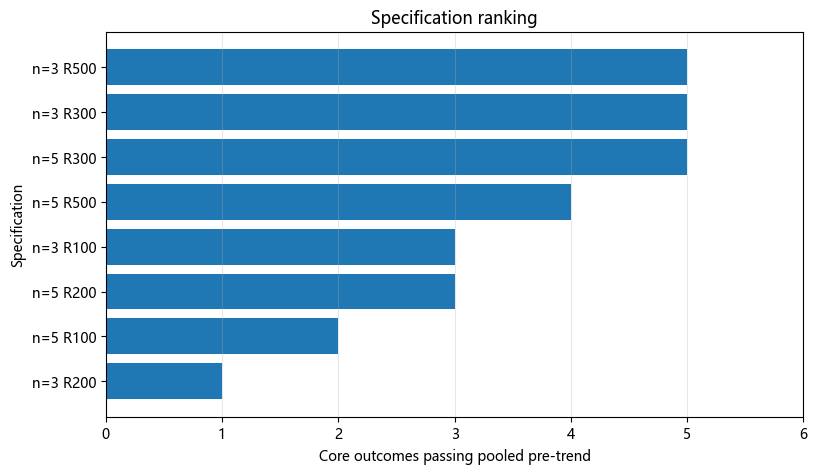

In [6]:
# 图1：8个规格 pooled 通过数
# ============================================================

plot_rank = (
    spec_ranking.copy()
)


plot_rank["label"] = (

    "n="
    +
    plot_rank[
        "window"
    ].astype(str)
    +
    " "
    +
    plot_rank[
        "scheme"
    ]
)


plot_rank = (
    plot_rank.sort_values(
        "rank",
        ascending=False
    )
)


plt.figure(
    figsize=(9, 5)
)


plt.barh(

    plot_rank[
        "label"
    ],

    plot_rank[
        "core_pooled_pass_count"
    ]
)


plt.xlabel(
    "Core outcomes passing pooled pre-trend"
)


plt.ylabel(
    "Specification"
)


plt.title(
    "Specification ranking"
)


plt.xlim(
    0,
    6
)


plt.grid(
    axis="x",
    alpha=0.3
)


plt.show()


# ============================================================


## 5.2 主结果变量的 Event Study 图

以活跃商户数为例，`rel_year=-1` 为基准。政策前 -3 和 -2 年的事件时间系数都接近 0，置信区间覆盖 0，且联合检验：

$$
p_{\mathrm{pre}}=0.740
$$

因此没有发现社区食堂出现以前近圈与远圈已经存在显著的差异趋势，活跃商户数的平行趋势假设得到数据支持。


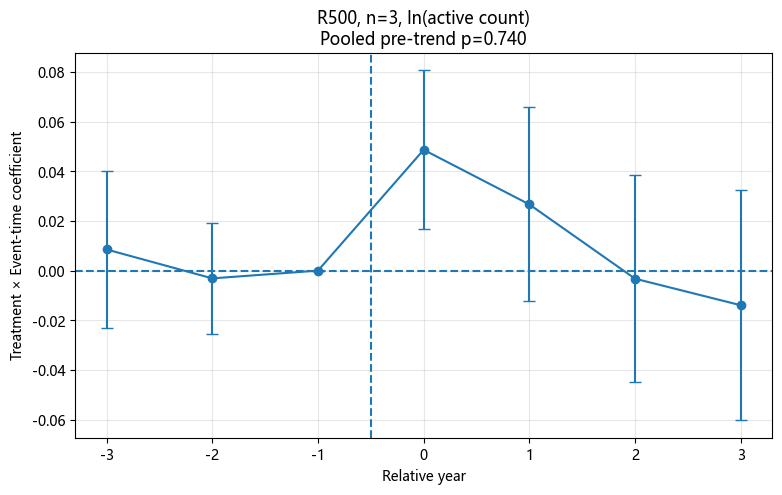

In [7]:
# 图2：
# 最优规格 ln_active_count Event Study
# ============================================================

best_event = (

    event_coef[

        (
            event_coef[
                "window"
            ]
            == BEST_WINDOW
        )

        &

        (
            event_coef[
                "scheme"
            ]
            == BEST_SCHEME
        )

        &

        (
            event_coef[
                "outcome"
            ]
            == "ln_active_count"
        )

    ]
    .sort_values(
        "rel_year"
    )
)


active_info = (
    analysis_summary[

        (
            analysis_summary[
                "window"
            ]
            == BEST_WINDOW
        )

        &

        (
            analysis_summary[
                "scheme"
            ]
            == BEST_SCHEME
        )

        &

        (
            analysis_summary[
                "outcome"
            ]
            == "ln_active_count"
        )

    ]
    .iloc[0]
)


pooled_p = (
    active_info[
        "pooled_pretrend_pvalue"
    ]
)


plt.figure(
    figsize=(9, 5)
)


plt.errorbar(

    best_event[
        "rel_year"
    ],

    best_event[
        "coef"
    ],

    yerr=[

        best_event[
            "coef"
        ]
        -
        best_event[
            "lower95"
        ],

        best_event[
            "upper95"
        ]
        -
        best_event[
            "coef"
        ],
    ],

    fmt="o-",

    capsize=4
)


plt.axhline(
    0,
    linestyle="--"
)


# -1 是baseline
# -0.5 分隔政策前后
plt.axvline(
    -0.5,
    linestyle="--"
)


plt.xlabel(
    "Relative year"
)


plt.ylabel(
    "Treatment × Event-time coefficient"
)


plt.title(
    f"{BEST_SCHEME}, "
    f"n={BEST_WINDOW}, "
    f"ln(active count)\n"
    f"Pooled pre-trend p={pooled_p:.3f}"
)


plt.grid(
    alpha=0.3
)


plt.show()


# ============================================================


## 5.3 最优规格下各指标的 pooled 事前 P 值

虚线表示 $p=0.10$。位于虚线右侧的指标通过 pooled 平行趋势复检。平均价格位于阈值左侧，因此后续不能作严格因果解释；同质化快餐小吃非常接近阈值，应谨慎解释。


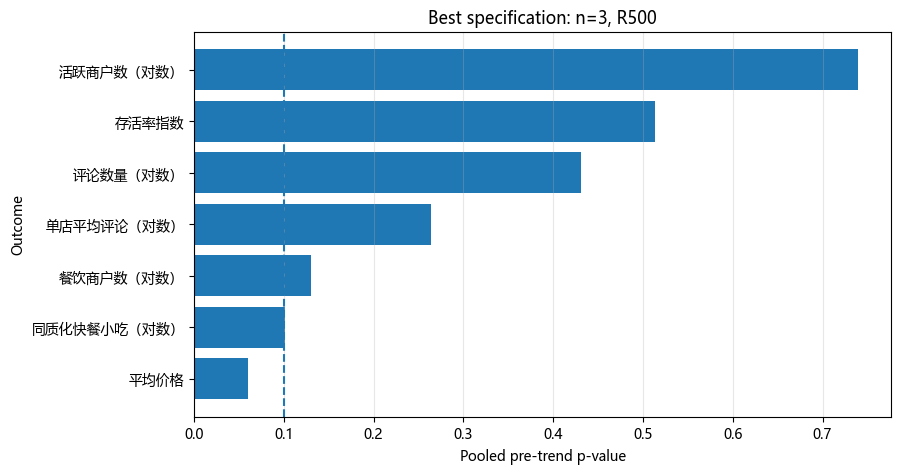

In [8]:
# 图3：
# 最优规格所有 outcome 的 pooled P
# ============================================================

best_outcomes = (
    analysis_summary[
        (
            analysis_summary[
                "window"
            ]
            == BEST_WINDOW
        )
        &
        (
            analysis_summary[
                "scheme"
            ]
            == BEST_SCHEME
        )
    ]
    .sort_values(
        "pooled_pretrend_pvalue"
    )
)


plt.figure(
    figsize=(9, 5)
)


plt.barh(

    best_outcomes[
        "outcome_name"
    ],

    best_outcomes[
        "pooled_pretrend_pvalue"
    ]
)


plt.axvline(
    0.10,
    linestyle="--"
)


plt.xlabel(
    "Pooled pre-trend p-value"
)


plt.ylabel(
    "Outcome"
)


plt.title(
    f"Best specification: "
    f"n={BEST_WINDOW}, "
    f"{BEST_SCHEME}"
)


plt.grid(
    axis="x",
    alpha=0.3
)


plt.show()


# ============================================================
# 保存排名
# ============================================================

spec_ranking.to_csv(

    OUT_DIR
    / "specification_ranking.csv",

    index=False,

    encoding="utf-8-sig"
)


vprint(
    "\n输出目录:",
    OUT_DIR
)


# 6. 主规格 DID 结果

主规格确定以后，不再比较 R100/R200/R300/R500，也不再重新选择 n=3/n=5。

对于每个结果变量，只使用该变量在第一层筛选中通过的设施，并在 `rel_year=-3` 到 `+3` 的样本内估计：

$$
Y_{irt}=\alpha_{ir}+\lambda_{it}
+\beta\left(Treat_r\times Post_{it}\right)+\varepsilon_{irt}
$$

其中 $\beta$ 为 DID 核心系数。对于对数变量，将其转换为百分比效应：

$$
Effect=(e^{\beta}-1)\times100\%
$$

### 主 DID 结果

| 指标 | Pooled 事前 P | DID 系数 | DID P 值 | 折算效应 | 解释 |
|---|---:|---:|---:|---:|---|
| 活跃商户数 | 0.740 | 0.0191 | 0.304 | +1.92% | 不显著 |
| 餐饮商户数 | 0.131 | 0.0120 | 0.596 | +1.21% | 不显著 |
| 同质化快餐小吃 | 0.101 | -0.0406 | 0.128 | -3.98% | 不显著 |
| 存活率指数 | 0.513 | 0.0736 | 0.275 | +0.0736 | 不显著 |
| 平均价格 | **0.060** | 8.8117 | 0.087 | +8.81 | **仅描述性** |
| 评论数量 | 0.431 | 0.0975 | **0.006** | **+10.24%** | **显著增加** |
| 单店平均评论 | 0.264 | 0.0808 | **0.006** | **+8.41%** | **显著增加** |

最明确的主结果来自评论活跃度：

$$
\widehat{Effect}_{comments}=+10.24\%,\qquad p=0.006
$$

$$
\widehat{Effect}_{avg\_comments}=+8.41\%,\qquad p=0.006
$$

两项均通过 pooled 平行趋势，因此可以在本研究设计下作进一步因果解释。相比之下，平均价格虽然 DID P 值较小，但事前趋势未通过，所以不能声称社区食堂导致周边价格上涨。


In [9]:
# ============================================================
# CELL 6
# 主规格正式 DID
# ============================================================

# 当前 Cell5 已经得到：
#
# BEST_SCHEME
# BEST_WINDOW
#
# 例如：
# BEST_SCHEME = "R500"
# BEST_WINDOW = 3


# ============================================================
# DID 回归函数
# ============================================================

def run_did_model(
    data,
    screen,
    scheme,
    outcome,
    window
):

    # --------------------------------------------------------
    # 1. 只使用：
    # 当前 scheme + window + outcome
    # 设施级平行趋势通过的设施
    # --------------------------------------------------------

    passed_ids = (
        screen[
            (screen["scheme"] == scheme)
            &
            (screen["window"] == window)
            &
            (screen["outcome"] == outcome)
            &
            (screen["parallel_pass"] == 1)
        ]["facility_id"]
        .astype(str)
        .unique()
    )

    if len(passed_ids) == 0:
        return None


    # --------------------------------------------------------
    # 2. 限制事件窗口
    #
    # n=3：
    # -3 ~ +3
    # --------------------------------------------------------

    d = data[
        (data["scheme"] == scheme)
        &
        (data["facility_id"].astype(str).isin(passed_ids))
        &
        (data["rel_year"].between(-window, window))
    ].copy()


    d = d.dropna(
        subset=[outcome]
    )


    if d.empty:
        return None


    # --------------------------------------------------------
    # 3. DID
    #
    # Treat × Post
    # --------------------------------------------------------

    d["post_did"] = (
        d["rel_year"] >= 0
    ).astype(float)

    d["did_reg"] = (
        d["treat_ring"].astype(float)
        *
        d["post_did"]
    )


    # --------------------------------------------------------
    # 4. 固定效应
    #
    # facility × ring FE
    #
    # facility × year FE
    # --------------------------------------------------------

    d["facility_ring_fe"] = (
        d["facility_id"].astype(str)
        + "_"
        + d["treat_ring"].astype(str)
    )

    d["facility_year_fe"] = (
        d["facility_id"].astype(str)
        + "_"
        + d["year"].astype(str)
    )


    absorb = pd.DataFrame({

        "facility_ring_fe":
            d["facility_ring_fe"]
            .astype("category"),

        "facility_year_fe":
            d["facility_year_fe"]
            .astype("category"),
    })


    y = (
        d[outcome]
        .astype(float)
    )


    X = pd.DataFrame({
        "did": d["did_reg"].astype(float)
    })


    # --------------------------------------------------------
    # 5. 回归
    # --------------------------------------------------------

    model = AbsorbingLS(

        dependent=y,

        exog=X,

        absorb=absorb,

        drop_absorbed=True
    )


    clusters = (
        d["facility_id"]
        .astype("category")
        .cat.codes
    )


    fit = model.fit(

        cov_type="clustered",

        clusters=clusters
    )


    beta = float(
        fit.params["did"]
    )

    se = float(
        fit.std_errors["did"]
    )

    pvalue = float(
        fit.pvalues["did"]
    )


    ci_low = (
        beta
        - 1.96 * se
    )

    ci_high = (
        beta
        + 1.96 * se
    )


    return {

        "scheme":
            scheme,

        "window":
            window,

        "outcome":
            outcome,

        "retained_facilities":
            len(passed_ids),

        "nobs":
            int(fit.nobs),

        "did_coef":
            beta,

        "did_se":
            se,

        "did_pvalue":
            pvalue,

        "ci95_low":
            ci_low,

        "ci95_high":
            ci_high,
    }


# ============================================================
# 跑所有主结果
# ============================================================

main_did_rows = []


for outcome in OUTCOMES:

    vprint(
        f"DID: {BEST_SCHEME} "
        f"n={BEST_WINDOW} "
        f"{outcome}"
    )


    result = run_did_model(

        data=panel,

        screen=facility_screen,

        scheme=BEST_SCHEME,

        outcome=outcome,

        window=BEST_WINDOW
    )


    if result is not None:

        main_did_rows.append(
            result
        )


main_did = pd.DataFrame(
    main_did_rows
)


# ============================================================
# 加 pooled 平行趋势结果
# ============================================================

pooled_best = (
    analysis_summary[
        (analysis_summary["scheme"] == BEST_SCHEME)
        &
        (analysis_summary["window"] == BEST_WINDOW)
    ][
        [
            "outcome",
            "pooled_pretrend_pvalue",
            "pooled_parallel_pass"
        ]
    ]
)


main_did = main_did.merge(

    pooled_best,

    on="outcome",

    how="left"
)


# ============================================================
# 指标名称
# ============================================================

main_did["outcome_name"] = (
    main_did["outcome"]
    .map(OUTCOMES)
)


# ============================================================
# 对数指标转百分比
# ============================================================

LOG_OUTCOMES = {

    "ln_active_count",
    "ln_food_count",
    "ln_fastfood_count",
    "ln_comments",
    "ln_avg_comments_per_shop",
}


def convert_effect(row):

    beta = row["did_coef"]

    if row["outcome"] in LOG_OUTCOMES:

        pct = (
            np.exp(beta)
            - 1
        ) * 100

        return pct

    return beta


main_did["effect"] = (
    main_did.apply(
        convert_effect,
        axis=1
    )
)


def effect_text(row):

    if row["outcome"] in LOG_OUTCOMES:

        return (
            f"{row['effect']:+.2f}%"
        )

    return (
        f"{row['effect']:+.4f}"
    )


main_did["effect_text"] = (
    main_did.apply(
        effect_text,
        axis=1
    )
)


# ============================================================
# 因果解释资格
#
# pooled pretrend p >= 0.10
# 才进入严格因果解释
# ============================================================

main_did["causal_status"] = np.where(

    main_did[
        "pooled_parallel_pass"
    ] == 1,

    "可作因果解释",

    "仅作描述性结果"
)


# ============================================================
# 展示
# ============================================================

main_did_display = (
    main_did[
        [
            "outcome_name",

            "retained_facilities",

            "pooled_pretrend_pvalue",

            "did_coef",

            "did_se",

            "did_pvalue",

            "effect_text",

            "causal_status",
        ]
    ]
    .copy()
)


# ============================================================

# 保存
# ============================================================

MAIN_DID_PATH = (
    OUT_DIR
    / "main_did_results.csv"
)


main_did.to_csv(

    MAIN_DID_PATH,

    index=False,

    encoding="utf-8-sig"
)


vprint(
    "保存:",
    MAIN_DID_PATH
)


# ============================================================


## 6.1 对数结果变量的百分比效应

为了避免不同量纲混在同一横轴，对数结果变量统一转换为百分比，并单独展示。横线为 95% 置信区间。


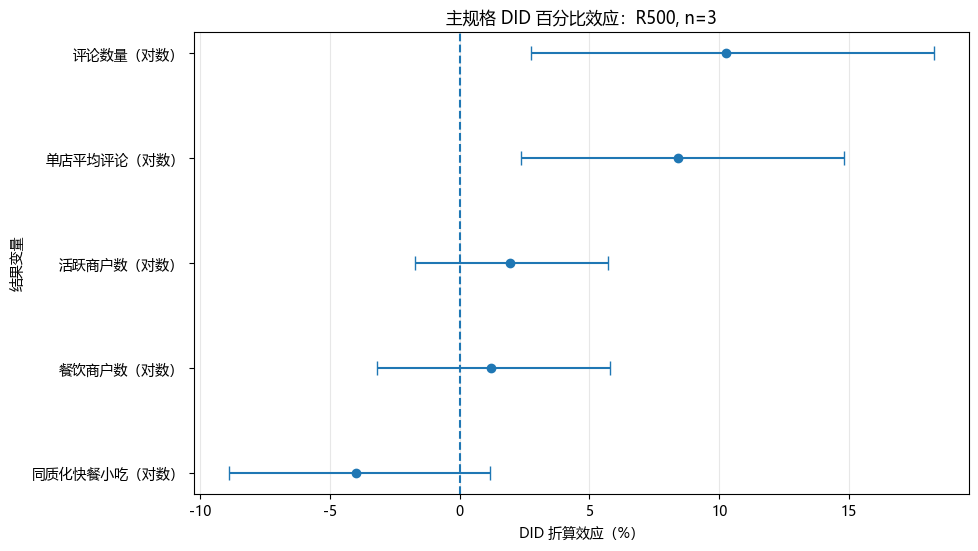

In [10]:
# 图1：对数指标 DID 百分比效应
# ============================================================

log_plot = main_did[
    main_did["outcome"].isin(LOG_OUTCOMES)
].copy()


# DID beta -> 百分比
log_plot["effect_pct"] = (
    np.exp(log_plot["did_coef"]) - 1
) * 100


# 95% CI 也转换成百分比
log_plot["ci_low_pct"] = (
    np.exp(log_plot["ci95_low"]) - 1
) * 100

log_plot["ci_high_pct"] = (
    np.exp(log_plot["ci95_high"]) - 1
) * 100


log_plot = log_plot.sort_values(
    "effect_pct"
)


plt.figure(figsize=(10, 6))

plt.errorbar(
    log_plot["effect_pct"],
    log_plot["outcome_name"],

    xerr=[
        log_plot["effect_pct"] - log_plot["ci_low_pct"],
        log_plot["ci_high_pct"] - log_plot["effect_pct"],
    ],

    fmt="o",
    capsize=5
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("DID 折算效应（%）")
plt.ylabel("结果变量")

plt.title(
    f"主规格 DID 百分比效应："
    f"{BEST_SCHEME}, n={BEST_WINDOW}"
)

plt.grid(
    axis="x",
    alpha=0.3
)

plt.show()

# ============================================================


## 6.2 非对数结果变量

存活率指数和平均价格保留原始尺度展示。平均价格面板中特别标记“仅描述性”，因为它没有通过 pooled 平行趋势复检。


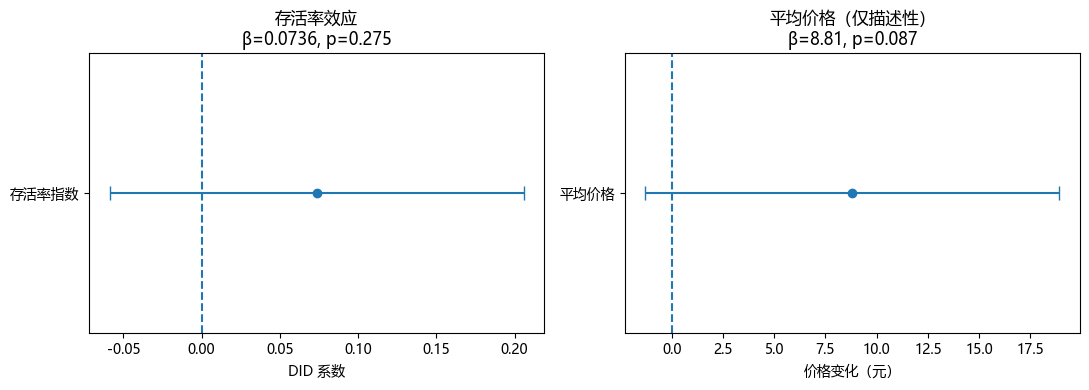

In [11]:
# 图2：非对数指标
# ============================================================

raw_plot = main_did[
    main_did["outcome"].isin(
        [
            "survival_index",
            "avg_price",
        ]
    )
].copy()


fig, axes = plt.subplots(
    1,
    2,
    figsize=(11, 4)
)


# ------------------------------------------------------------
# 存活率
# ------------------------------------------------------------

x = raw_plot[
    raw_plot["outcome"]
    == "survival_index"
].iloc[0]


axes[0].errorbar(
    x["did_coef"],
    0,

    xerr=[[
        x["did_coef"] - x["ci95_low"]
    ], [
        x["ci95_high"] - x["did_coef"]
    ]],

    fmt="o",
    capsize=5
)

axes[0].axvline(
    0,
    linestyle="--"
)

axes[0].set_yticks([0])
axes[0].set_yticklabels(
    ["存活率指数"]
)

axes[0].set_xlabel(
    "DID 系数"
)

axes[0].set_title(
    f"存活率效应\n"
    f"β={x['did_coef']:.4f}, "
    f"p={x['did_pvalue']:.3f}"
)


# ------------------------------------------------------------
# 平均价格
# ------------------------------------------------------------

x = raw_plot[
    raw_plot["outcome"]
    == "avg_price"
].iloc[0]


axes[1].errorbar(
    x["did_coef"],
    0,

    xerr=[[
        x["did_coef"] - x["ci95_low"]
    ], [
        x["ci95_high"] - x["did_coef"]
    ]],

    fmt="o",
    capsize=5
)

axes[1].axvline(
    0,
    linestyle="--"
)

axes[1].set_yticks([0])
axes[1].set_yticklabels(
    ["平均价格"]
)

axes[1].set_xlabel(
    "价格变化（元）"
)

axes[1].set_title(
    f"平均价格（仅描述性）\n"
    f"β={x['did_coef']:.2f}, "
    f"p={x['did_pvalue']:.3f}"
)


plt.tight_layout()
plt.show()


# 7. 异质性分析

总体样本满足平行趋势并不意味着每一种商户类型也自动满足，因此异质性分析固定使用 R500、n=3 后，对每个 subgroup **重新构造活跃商户数量、重新做设施级平行趋势、重新做 pooled Event Study，最后再做该分组的 DID**。

分组包括：

- 餐饮商户；
- 同质化快餐小吃；
- 其他餐饮；
- 非餐饮商户；
- 低价餐饮（有效价格 $\le 30$ 元）；
- 中高价餐饮（有效价格 $>30$ 元）。

### 异质性结果

| 分组 | Pooled 事前 P | DID P 值 | 折算效应 | 解释 |
|---|---:|---:|---:|---|
| 餐饮商户 | 0.131 | 0.596 | +1.21% | 不显著 |
| 同质化快餐小吃 | 0.101 | 0.128 | -3.98% | 不显著 |
| 其他餐饮 | **0.069** | **0.008** | +6.37% | **仅描述性** |
| 非餐饮商户 | 0.629 | 0.633 | +0.88% | 不显著 |
| 低价餐饮 | 0.168 | 0.058 | +10.29% | 10% 水平附近显著 |
| 中高价餐饮 | 0.309 | **0.0002** | **+20.79%** | **显著增加** |

低价餐饮结果为：

$$
\widehat{Effect}_{low}=+10.29\%,\qquad p=0.058,\qquad p_{\mathrm{pre}}=0.168
$$

中高价餐饮结果为：

$$
\widehat{\mathrm{Effect}}_{\mathrm{mid/high}}=+20.79\%,\qquad p=0.0002,\qquad p_{\mathrm{pre}}=0.309
$$

“其他餐饮”虽然 DID 显著，但：

$$
p_{\mathrm{pre}}=0.069<0.10
$$

因此只能报告为描述性现象，不能作为严格因果结论。这也说明异质性分析中重新检验平行趋势是必要的。


In [12]:
# ============================================================
# CELL 7
# 异质性分析
#
# 固定：
# BEST_SCHEME
# BEST_WINDOW
#
# 每个 subgroup：
#
# 重新空间聚合
# → 设施平行趋势
# → pooled Event Study
# → DID
# ============================================================


# ============================================================
# 1. 异质性分组定义
# ============================================================

SUBGROUPS = {

    "food":
        "餐饮商户",

    "fastfood":
        "同质化快餐小吃",

    "other_food":
        "其他餐饮",

    "nonfood":
        "非餐饮商户",

    "low_price_food":
        "低价餐饮（<=30元）",

    "high_price_food":
        "中高价餐饮（>30元）",
}


best_cfg = (
    SCHEMES[
        BEST_SCHEME
    ]
)


treat_max = (
    best_cfg[
        "treat_max"
    ]
)


control_max = (
    best_cfg[
        "control_max"
    ]
)


vprint(
    "异质性固定规格:"
)

vprint(
    BEST_SCHEME,
    best_cfg["label"]
)

vprint(
    "window:",
    BEST_WINDOW
)


# ============================================================
# 2. 设施
# ============================================================

fac_het = con.execute("""
SELECT

    facility_id,
    opening_year,

    name,

    lon_wgs,
    lat_wgs,

    province19,
    city19,
    county19

FROM facilities_clean
""").df()


fac_het["facility_id"] = (
    fac_het[
        "facility_id"
    ].astype(str)
)


fac_rad = np.radians(

    fac_het[
        [
            "lat_wgs",
            "lon_wgs"
        ]
    ].to_numpy()
)


# ============================================================
# 3. 重新按 BEST_SCHEME 匹配商户
#
# 不再跑四个 scheme，
# 只跑已经选好的主规格
# ============================================================

hetero_annual = []


for year in range(
    2012,
    2023
):

    vprint(
        f"heterogeneity spatial year {year}"
    )


    shops = con.execute(f"""
        SELECT

            shop_id,

            lon_wgs,
            lat_wgs,

            is_food,
            is_homogeneous_fastfood,

            is_closed,

            avg_price

        FROM shops_clean

        WHERE year = {year}
    """).df()


    if shops.empty:
        continue


    shops["shop_id"] = (
        shops["shop_id"]
        .astype(str)
    )


    coords = np.radians(

        shops[
            [
                "lat_wgs",
                "lon_wgs"
            ]
        ].to_numpy()
    )


    tree = BallTree(

        coords,

        metric="haversine"
    )


    indexes, distances = (
        tree.query_radius(

            fac_rad,

            r=(
                control_max
                /
                EARTH_RADIUS_KM
            ),

            return_distance=True,

            sort_results=True
        )
    )


    pair_blocks = []


    for i, (
        idx,
        dist
    ) in enumerate(
        zip(
            indexes,
            distances
        )
    ):

        if len(idx) == 0:
            continue


        x = (
            shops.iloc[
                idx
            ]
            .copy()
        )


        x["facility_id"] = (
            fac_het.iloc[i][
                "facility_id"
            ]
        )


        x["opening_year"] = (
            fac_het.iloc[i][
                "opening_year"
            ]
        )


        x["distance_km"] = (
            dist
            *
            EARTH_RADIUS_KM
        )


        # 社区食堂自身剔除
        x = x[
            x["shop_id"]
            !=
            x["facility_id"]
        ]


        pair_blocks.append(
            x
        )


    if not pair_blocks:
        continue


    pairs = pd.concat(
        pair_blocks,
        ignore_index=True
    )


    # ========================================================
    # Treat / Control
    # ========================================================

    pairs["scheme"] = (
        BEST_SCHEME
    )


    pairs["treat_ring"] = (
        pairs[
            "distance_km"
        ]
        <= treat_max
    ).astype("int8")


    # ========================================================
    # 对照组污染
    #
    # 必须在 subgroup 分类之前处理
    # ========================================================

    treated_shop_ids = set(

        pairs.loc[
            pairs[
                "treat_ring"
            ] == 1,

            "shop_id"
        ]
    )


    pairs = pairs[
        ~(
            (
                pairs[
                    "treat_ring"
                ] == 0
            )
            &
            (
                pairs[
                    "shop_id"
                ].isin(
                    treated_shop_ids
                )
            )
        )
    ].copy()


    # ========================================================
    # nullable integer 统一处理
    # ========================================================

    pairs["is_closed_num"] = (

        pd.to_numeric(
            pairs["is_closed"],
            errors="coerce"
        )
        .fillna(0)
        .astype("int8")
    )


    pairs["is_food_num"] = (

        pd.to_numeric(
            pairs["is_food"],
            errors="coerce"
        )
        .fillna(0)
        .astype("int8")
    )


    pairs["is_fastfood_num"] = (

        pd.to_numeric(
            pairs[
                "is_homogeneous_fastfood"
            ],
            errors="coerce"
        )
        .fillna(0)
        .astype("int8")
    )


    pairs["active"] = np.where(

        pairs[
            "is_closed_num"
        ] == 1,

        0,

        1

    ).astype("int8")


    # ========================================================
    # 4. 六个 subgroup
    # ========================================================

    masks = {

        "food":
            (
                pairs[
                    "is_food_num"
                ] == 1
            ),

        "fastfood":
            (
                pairs[
                    "is_fastfood_num"
                ] == 1
            ),

        "other_food":
            (
                (
                    pairs[
                        "is_food_num"
                    ] == 1
                )
                &
                (
                    pairs[
                        "is_fastfood_num"
                    ] == 0
                )
            ),

        "nonfood":
            (
                pairs[
                    "is_food_num"
                ] == 0
            ),

        # 文档：
        # 有价格的餐饮按30元分组
        "low_price_food":
            (
                (
                    pairs[
                        "is_food_num"
                    ] == 1
                )
                &
                (
                    pairs[
                        "avg_price"
                    ].notna()
                )
                &
                (
                    pairs[
                        "avg_price"
                    ] <= 30
                )
            ),

        "high_price_food":
            (
                (
                    pairs[
                        "is_food_num"
                    ] == 1
                )
                &
                (
                    pairs[
                        "avg_price"
                    ].notna()
                )
                &
                (
                    pairs[
                        "avg_price"
                    ] > 30
                )
            ),
    }


    # ========================================================
    # 每个 subgroup 聚合 active_count
    # ========================================================

    for subgroup, mask in masks.items():

        z = (
            pairs[
                mask
            ]
            .copy()
        )


        if z.empty:
            continue


        g = (
            z.groupby(
                [
                    "facility_id",
                    "opening_year",
                    "scheme",
                    "treat_ring"
                ],
                as_index=False
            )
            .agg(

                active_count=(
                    "active",
                    "sum"
                )
            )
        )


        g["year"] = year

        g["subgroup"] = subgroup


        hetero_annual.append(
            g
        )


# ============================================================
# 5. 合并
# ============================================================

hetero_raw = pd.concat(

    hetero_annual,

    ignore_index=True
)


# ============================================================
# 6. 每个 subgroup 建完整平衡面板
#
# facility × ring × year
# ============================================================

hetero_panels = []


for subgroup in SUBGROUPS:

    grid = (
        pd.MultiIndex
        .from_product(

            [
                fac_het[
                    "facility_id"
                ],

                [0, 1],

                range(
                    2012,
                    2023
                ),
            ],

            names=[
                "facility_id",
                "treat_ring",
                "year",
            ]
        )
        .to_frame(
            index=False
        )
    )


    x = (
        grid.merge(

            fac_het[
                [
                    "facility_id",
                    "opening_year",
                    "name",
                    "lon_wgs",
                    "lat_wgs",
                    "province19",
                    "city19",
                    "county19",
                ]
            ],

            on="facility_id",

            how="left"
        )
    )


    agg = hetero_raw[
        hetero_raw[
            "subgroup"
        ] == subgroup
    ][
        [
            "facility_id",
            "treat_ring",
            "year",
            "active_count"
        ]
    ]


    x = x.merge(

        agg,

        on=[
            "facility_id",
            "treat_ring",
            "year"
        ],

        how="left"
    )


    # 没有该类商户 = 0
    x["active_count"] = (
        x["active_count"]
        .fillna(0)
    )


    x["scheme"] = (
        BEST_SCHEME
    )


    x["subgroup"] = (
        subgroup
    )


    x["rel_year"] = (
        x["year"]
        -
        x["opening_year"]
    )


    x["post"] = (
        x["rel_year"]
        >= 0
    ).astype("int8")


    x["did"] = (
        x["treat_ring"]
        *
        x["post"]
    )


    x["ln_active_count"] = (
        np.log1p(
            x[
                "active_count"
            ]
        )
    )


    hetero_panels.append(
        x
    )


hetero_panel = pd.concat(

    hetero_panels,

    ignore_index=True
)


vprint(
    "heterogeneity panel rows:",
    len(hetero_panel)
)


# ============================================================
# 7. 每个 subgroup：
#
# 设施级平行趋势
# + pooled Event Study
# + DID
# ============================================================

hetero_screen_list = []
hetero_event_list = []
hetero_result_rows = []


for subgroup, subgroup_name in SUBGROUPS.items():

    vprint(
        "\n===================================="
    )

    vprint(
        subgroup_name
    )

    vprint(
        "===================================="
    )


    sub_panel = (
        hetero_panel[
            hetero_panel[
                "subgroup"
            ] == subgroup
        ]
        .copy()
    )


    # --------------------------------------------------------
    # 7.1 设施平行趋势
    # --------------------------------------------------------

    screen = facility_pretrend(

        panel=sub_panel,

        scheme=BEST_SCHEME,

        outcome="ln_active_count",

        window=BEST_WINDOW
    )


    screen["subgroup"] = (
        subgroup
    )


    screen[
        "subgroup_name"
    ] = (
        subgroup_name
    )


    hetero_screen_list.append(
        screen
    )


    testable = int(
        screen[
            "testable"
        ].sum()
    )


    passed = int(
        screen[
            "parallel_pass"
        ].sum()
    )


    pass_rate = (

        passed / testable

        if testable > 0

        else np.nan
    )


    # --------------------------------------------------------
    # 7.2 pooled Event Study
    # --------------------------------------------------------

    pooled, coef_df = (
        pooled_event_study(

            panel=sub_panel,

            facility_screen=
                screen,

            scheme=
                BEST_SCHEME,

            outcome=
                "ln_active_count",

            window=
                BEST_WINDOW
        )
    )


    if pooled is None:

        pooled_p = np.nan
        pooled_pass = 0

    else:

        pooled_p = (
            pooled[
                "pooled_pretrend_pvalue"
            ]
        )

        pooled_pass = (
            pooled[
                "pooled_parallel_pass"
            ]
        )


    if coef_df is not None:

        coef_df[
            "subgroup"
        ] = subgroup

        coef_df[
            "subgroup_name"
        ] = subgroup_name

        hetero_event_list.append(
            coef_df
        )


    # --------------------------------------------------------
    # 7.3 DID
    # --------------------------------------------------------

    did_result = run_did_model(

        data=sub_panel,

        screen=screen,

        scheme=BEST_SCHEME,

        outcome=
            "ln_active_count",

        window=
            BEST_WINDOW
    )


    if did_result is None:

        beta = np.nan
        did_se = np.nan
        did_p = np.nan
        effect_pct = np.nan
        retained = 0

    else:

        beta = (
            did_result[
                "did_coef"
            ]
        )

        did_se = (
            did_result[
                "did_se"
            ]
        )

        did_p = (
            did_result[
                "did_pvalue"
            ]
        )

        retained = (
            did_result[
                "retained_facilities"
            ]
        )

        effect_pct = (
            np.exp(beta)
            - 1
        ) * 100


    hetero_result_rows.append({

        "subgroup":
            subgroup,

        "subgroup_name":
            subgroup_name,

        "scheme":
            BEST_SCHEME,

        "window":
            BEST_WINDOW,

        "testable_facilities":
            testable,

        "passed_facilities":
            passed,

        "facility_pass_rate":
            pass_rate,

        "pooled_pretrend_pvalue":
            pooled_p,

        "pooled_parallel_pass":
            pooled_pass,

        "retained_facilities":
            retained,

        "did_coef":
            beta,

        "did_se":
            did_se,

        "did_pvalue":
            did_p,

        "effect_pct":
            effect_pct,

        "causal_status":
            (
                "可作因果解释"
                if pooled_pass == 1
                else
                "仅作描述性结果"
            ),
    })


# ============================================================
# 8. 汇总
# ============================================================

hetero_screen = pd.concat(

    hetero_screen_list,

    ignore_index=True
)


hetero_results = pd.DataFrame(

    hetero_result_rows
)


if hetero_event_list:

    hetero_event_coef = (
        pd.concat(
            hetero_event_list,
            ignore_index=True
        )
    )

else:

    hetero_event_coef = (
        pd.DataFrame()
    )


hetero_results[
    "facility_pass_rate_pct"
] = (
    hetero_results[
        "facility_pass_rate"
    ]
    * 100
)


hetero_results[
    "effect_text"
] = (
    hetero_results[
        "effect_pct"
    ]
    .map(
        lambda x:
        f"{x:+.2f}%"
        if pd.notna(x)
        else ""
    )
)


# ============================================================
# 9. 展示
# ============================================================

# ============================================================

# 11. 保存
# ============================================================

hetero_panel.to_parquet(

    OUT_DIR
    / "heterogeneity_panel.parquet",

    compression="zstd",

    index=False
)


hetero_screen.to_csv(

    OUT_DIR
    / "heterogeneity_facility_pretrend_screen.csv",

    index=False,

    encoding="utf-8-sig"
)


hetero_results.to_csv(

    OUT_DIR
    / "heterogeneity_results.csv",

    index=False,

    encoding="utf-8-sig"
)


if not hetero_event_coef.empty:

    hetero_event_coef.to_csv(

        OUT_DIR
        / "heterogeneity_event_study_coefficients.csv",

        index=False,

        encoding="utf-8-sig"
    )


vprint(
    "\n异质性分析完成"
)


## 7.1 各商户类型 DID 效应

下图比较不同 subgroup 的活跃商户数量百分比效应。图形只展示估计大小；是否可以进行因果解释仍必须结合该 subgroup 自己的 pooled 平行趋势结果。


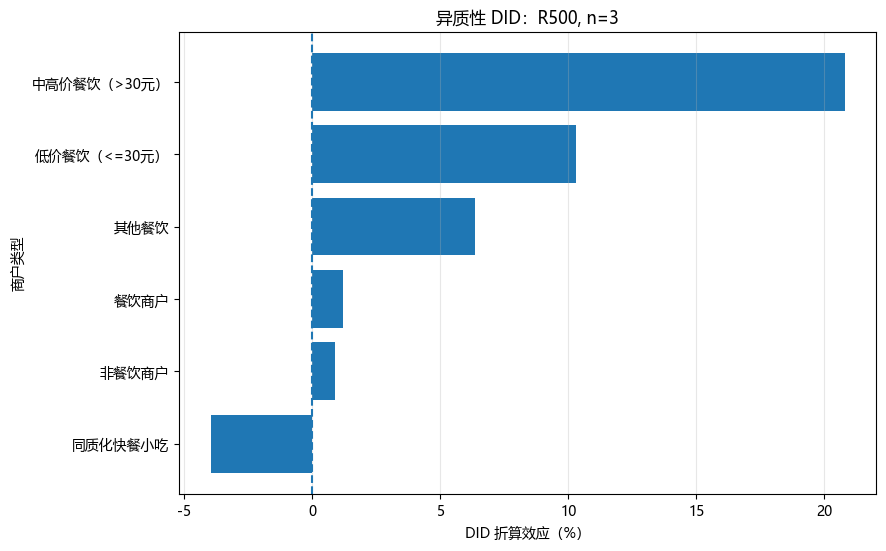

In [13]:
# 10. 可视化
# ============================================================

plot_het = (
    hetero_results
    .sort_values(
        "effect_pct"
    )
)


plt.figure(
    figsize=(9, 6)
)


plt.barh(

    plot_het[
        "subgroup_name"
    ],

    plot_het[
        "effect_pct"
    ]
)


plt.axvline(
    0,
    linestyle="--"
)


plt.xlabel(
    "DID 折算效应（%）"
)


plt.ylabel(
    "商户类型"
)


plt.title(
    f"异质性 DID："
    f"{BEST_SCHEME}, "
    f"n={BEST_WINDOW}"
)


plt.grid(
    axis="x",
    alpha=0.3
)


plt.show()


# ============================================================


## 7.2 各异质性分组的 pooled 平行趋势

虚线为 $p=0.10$。其他餐饮未通过，而低价餐饮和中高价餐饮均通过，因此后两者的 DID 可以进入进一步因果解释。


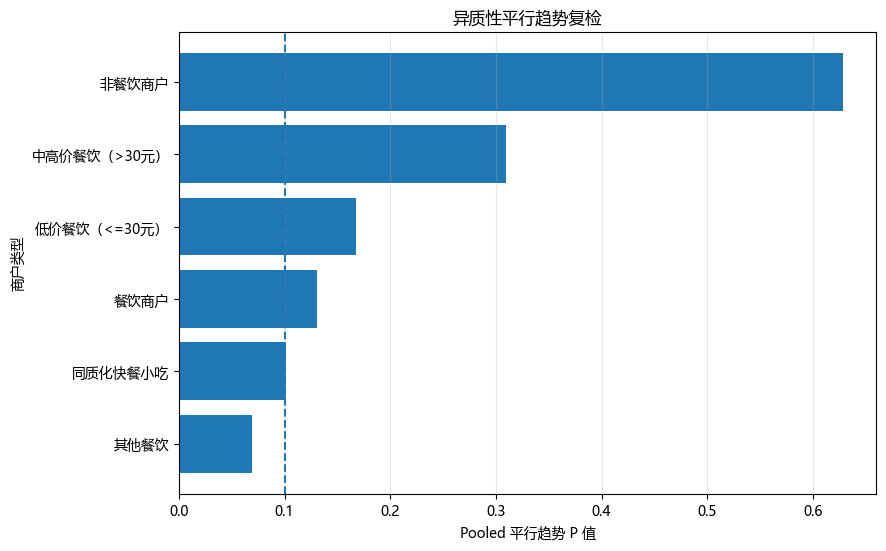

In [14]:
# pooled P 图
# ============================================================

plot_p = (
    hetero_results
    .sort_values(
        "pooled_pretrend_pvalue"
    )
)


plt.figure(
    figsize=(9, 6)
)


plt.barh(

    plot_p[
        "subgroup_name"
    ],

    plot_p[
        "pooled_pretrend_pvalue"
    ]
)


plt.axvline(
    0.10,
    linestyle="--"
)


plt.xlabel(
    "Pooled 平行趋势 P 值"
)


plt.ylabel(
    "商户类型"
)


plt.title(
    "异质性平行趋势复检"
)


plt.grid(
    axis="x",
    alpha=0.3
)


plt.show()


# ============================================================


# 8. 结论与解释边界

## 8.1 主要发现

1. 在 8 种候选设计中，**R500 + n=3** 的整体识别表现最好。
2. 该主规格下，6 个核心指标中 **5/6 通过 pooled 平行趋势复检**。
3. 没有发现社区食堂出现后周边活跃商户总量、餐饮商户总量或存活率发生显著变化。
4. 周边商业的**评论活跃度显著上升**：评论数量约 +10.24%，单店平均评论约 +8.41%。
5. 异质性结果显示，中高价餐饮活跃商户数量约 +20.79%，且该分组通过自己的 pooled 平行趋势检验。
6. 平均价格和其他餐饮的部分显著结果由于政策前趋势不满足要求，只能作描述性解释。

## 8.2 与原研究说明的对应关系

| 原说明中的模块 | 本报告对应章节 |
|---|---|
| 数据清洗与社区食堂设施 | 第 1-2 节 |
| 空间环带和平衡面板 | 第 2 节 |
| 表 2：设施层平行趋势 | 第 3 节 |
| pooled Event Study | 第 4 节 |
| 表 4：规格选择 | 第 5 节 |
| 表 3：主 DID | 第 6 节 |
| 表 5：异质性分析 | 第 7 节 |

## 8.3 解释边界

- `opening_year` 是社区食堂**第一次在年度点评数据中被观测到**的年份，并非工商注册意义上的精确开业日期。
- $p_{\mathrm{pre}}\ge0.10$ 只表示没有检测到显著政策前差异趋势，不能理解为平行趋势被严格证明。
- 空间 DID 假定稍远环带能够代表同一局部市场的反事实变化；若社区食堂影响扩散到对照圈，估计效应可能被稀释。
- 本次数据版本、社区食堂识别方式和平台覆盖与原报告可能不同，因此设施数量与估计数值不要求完全复现；需要保持一致的是事件时间、空间处理设计、平行趋势筛选和 DID 识别逻辑。

> **总体结论：** 在通过设施级筛选和 pooled Event Study 复检的结果变量上，本研究没有发现社区食堂显著改变周边商户总量，但观察到周边商业评论活跃度上升，并在部分餐饮价格分组中发现正向数量效应。
